# Wstępna eksploracyjna analiza danych (EDA) - Etap 2. projektu

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

DATASET_PATH = "../data/default_of_credit_card_clients.xls"

data = pd.read_excel(DATASET_PATH)

## Krok 1: Weryfikacja jakości i czyszczenie danych

In [161]:
data.columns

Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [162]:
# Rename column to match column names from dataset's variable description
column_names = data.columns

data.rename(columns={f"{column_names[0]}": "ID"}, inplace=True)

print(data.columns)

Index(['ID', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20',
       'X21', 'X22', 'X23', 'Y'],
      dtype='object')


In [163]:
# Extract row 0 (first data row) as description dict
description_dict = {col: data.loc[0, col] for col in data.columns}

# Drop row 0 and reset index
data = data.drop(0).reset_index(drop=True)

# Infer column types based on column values
data = data.infer_objects()
data = data.astype({"Y": bool})

In [164]:
print(f"column types:\n{data.dtypes}")

column types:
ID     int64
X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
X17    int64
X18    int64
X19    int64
X20    int64
X21    int64
X22    int64
X23    int64
Y       bool
dtype: object


### Sprawdzenie brakujących wartości i zduplikowanych wierszy

In [165]:
# Sprawdzenie czy zbiór danych zawiera brakujące wartości (NaN)
missing = data.isnull().sum()
missing_result = "nie zawiera" if missing.sum() == 0 else f"zawiera {missing.sum()}"

print(f"Zbiór danych {missing_result} brakujących wartości")

Zbiór danych nie zawiera brakujących wartości


In [166]:
# Sprawdzenie czy zbiór danych zawiera zduplikowane wiersze
duplicated = data.duplicated().sum()
duplicated_result = "nie zawiera" if duplicated == 0 else f"zawiera {duplicated}"

print(f"Zbior danych {duplicated_result} zduplikowanych wierszy")

Zbior danych nie zawiera zduplikowanych wierszy


### Infomacja o zbiorze

Wszystkie kwoty są podane w dolarach tajwańskich

| Nazwa zmiennej | Inna nazwa | Opis |
|----------------| -- | -- |
| X1             | LIMIT_BAL | Kwota udzielonego kredytu |
| X2             | SEX | Płeć (1 = mężczyzna, 2 = kobieta) |
| X3             | EDUCATION | Wykształcenie (1 = studia podyplomowe, 2 = studia wyższe, 3 = szkoła średnia, 4 = inne) |
| X4             | MARRIAGE | Stan cywilny (1 = married, 2 = single, 3 = others) |
| X5             | AGE | Wiek |
| --             | -- |
| X6 - X11       | -- | Historia spłat (od kwietnia do września 2005r.) Status spłaty (-1 = spłata terminowa, 1 = opóżnienie płatności o jeden miesiąc, 2 = opóżnienie płatności o dwa miesiące, ..., 8 = opóźnienie płatności o osiem miesięcy, 9 = opóźnienie płatności o dziewięć miesięcy i więcej) |
| --             | -- | -- |
| X6             | PAY_0 | Status spłaty we wrześniu 2005r. |
| X7             | PAY_2 | Status spłaty w sierpniu 2005r. |
| X8             | PAY_3 | Status spłaty w lipcu 2005r. |
| X9             | PAY_4 | Status spłaty w czerwcu 2005r. |
| X10            | PAY_5 | Status spłaty w maju 2005r. |
| X11            | PAY_6 | Status spłaty w kwietniu 2005r. |
| --             | -- | -- |
| X12 - X17      | -- | Kwota rachunku |
| --             | -- | -- |
| X12            | BILL_AMT1 | Kwota rachunku we wrześniu 2005r. |
| X13            | BILL_AMT2 | Kwota rachunku w sierpniu 2005r. |
| X14            | BILL_AMT3 | Kwota rachunku w lipcu 2005r. |
| X15            | BILL_AMT4 | Kwota rachunku w czerwcu 2005r. |
| X16            | BILL_AMT5 | Kwota rachunku w maju 2005r.|
| X17            | BILL_AMT6 | Kwota rachunku w kwietniu 2005r. |
| --             | -- | -- |
| X18 - X23      | -- | Kwota poprzedniej płatności (od kwietnia do września 2005r.) |
| --             | -- |
| X18            | PAY_AMT1 | Kwota zapłacona we wrześniu 2005r. |
| X19            | PAY_AMT2 | Kwota zapłacona w sierpniu 2005r. |
| X20            | PAY_AMT3 | Kwota zapłacona w lipcu 2005r. |
| X21            | PAY_AMT4 | Kwota zapłacona w czerwcu 2005r. |
| X22            | PAY_AMT5 | Kwota zapłacona w maju 2005r. |
| X23            | PAY_AMT6 | Kwota zapłacona w kwietniu 2005r. |
| --             | -- | -- |
| Y              | default payment next month | Zaległość w spłacie (1 = Tak, 0 = Nie) |

### Sprawdzenie potencjalnych błędów w zmiennych kategorycznych

In [167]:
def find_not_allowed_values(dataset: pd.DataFrame, feature_name, allowed_values):
    values_raw = pd.DataFrame(dataset[feature_name].value_counts()).T.columns.tolist()
    not_allowed_values = data[~data[feature_name].isin(allowed_values)]
    return not_allowed_values


#### Cecha X2 (Sex)

In [168]:
# wartości cechy X2 (Sex - Gender (1 = male; 2 = female))
sex_values_raw = pd.DataFrame(data["X2"].value_counts()).T
sex_values = sex_values_raw.rename(columns={2: "Female (2)", 1: "Male (1)"}, inplace=False)

print(sex_values)

X2     Female (2)  Male (1)
count       18112     11888


In [169]:
sex_not_allowed_values = find_not_allowed_values(dataset=data, feature_name="X2", allowed_values=[1,2])

if not sex_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy X2 (Sex)")
    print(sex_not_allowed_values)

#### Cecha X3 (Education Level)

In [170]:
# wartości cechy X3 (Education Level (1 = graduate school; 2 = university; 3 = high school; 4 = others))
education_values_raw = pd.DataFrame(data["X3"].value_counts()).T
education_values = education_values_raw.rename(columns={1: "graduate school (1)", 2: "university (2)", 3: "high school (3)", 4: "others (4)"}, inplace=False)

print(education_values)

X3     university (2)  graduate school (1)  high school (3)    5  others (4)  \
count           14030                10585             4917  280         123   

X3      6   0  
count  51  14  


In [171]:
education_not_allowed_values = find_not_allowed_values(dataset=data, feature_name="X3", allowed_values=[1,2, 3, 4])

if not education_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy X3 (Education Level)")
    display(education_not_allowed_values)

Dane dla nieprawidłowych wartości cechy X3 (Education Level)


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
47,48,150000,2,5,2,46,0,0,-1,0,0,-2,4463,3034,1170,1170,0,0,1013,1170,0,0,0,0,True
69,70,20000,1,5,2,22,2,0,0,0,0,0,18565,17204,17285,18085,11205,5982,0,1200,1000,500,1000,0,False
385,386,410000,2,5,1,42,0,0,0,0,0,0,338106,342904,344464,240865,234939,240176,15000,14000,9000,8500,9000,8300,False
502,503,230000,2,6,2,46,0,0,0,0,0,0,221590,227397,230302,186635,189896,193351,10000,9000,8000,8000,7500,7000,False
504,505,30000,1,6,1,53,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29811,29812,50000,1,5,2,46,0,0,0,-1,0,0,49336,49623,19900,19183,19563,19157,1423,1000,19183,687,696,776,False
29836,29837,180000,1,6,1,34,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,False
29839,29840,150000,1,5,1,36,0,0,0,0,0,0,216482,220889,133616,136378,139219,142172,5500,3800,3900,4000,4100,4100,False
29920,29921,50000,1,5,1,45,2,0,0,0,0,0,71927,73514,75373,50947,51020,0,3000,3428,2002,1023,0,0,True


#### Cecha X4 (Marital Status)

In [172]:
# wartości cechy X4 (Marital status (1 = married; 2 = single; 3 = others))
marital_status_values = pd.DataFrame(data["X4"].value_counts()).T
marital_status_values.rename(columns={1: "married (1)", 2: "single (2)", 3: "others (3)"}, inplace=True)

print(marital_status_values)

X4     single (2)  married (1)  others (3)   0
count       15964        13659         323  54


In [173]:
marital_status_not_allowed_values = find_not_allowed_values(dataset=data, feature_name="X4", allowed_values=[1,2, 3])

if not marital_status_not_allowed_values.empty:
    print(f"Dane dla nieprawidłowych wartości cechy X4 (Marital Status)")
    display(marital_status_not_allowed_values)

Dane dla nieprawidłowych wartości cechy X4 (Marital Status)


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
218,219,110000,2,3,0,31,0,0,0,0,0,0,89989,84229,79288,73315,63818,63208,4000,5000,3000,3000,3000,8954,False
809,810,160000,2,2,0,37,0,0,0,0,0,0,2694,38433,38870,28574,27268,28021,35888,1325,891,1000,1098,426,False
820,821,200000,2,3,0,51,-1,-1,-1,-1,0,-1,780,0,390,780,390,390,0,390,780,0,390,390,False
1019,1020,180000,2,3,0,45,-1,-1,-2,-2,-2,-2,4148,0,0,0,0,0,0,0,0,0,0,0,False
1443,1444,200000,1,3,0,51,-1,-1,-1,-1,0,-1,3556,4993,9212,2529,1036,4430,5020,9236,2529,0,4430,6398,False
2146,2147,150000,2,3,0,55,-1,-1,-1,-1,-1,-1,1080,17493,9160,2939,3396,1870,17498,9160,2939,3396,1870,6800,False
2554,2555,220000,2,1,0,33,-1,-1,-1,-1,-1,-1,3378,1531,942,608,1738,277,1531,942,608,1738,277,492,False
3056,3057,200000,1,3,0,36,-2,-2,-2,-2,-2,-2,5644,82620,14129,41359,9140,0,89187,14178,41359,9140,0,0,False
4470,4471,70000,1,3,0,35,2,2,2,2,2,2,47702,48839,49636,50517,51658,52758,2200,1900,2000,2100,2100,2000,False
5005,5006,90000,2,3,0,24,-2,-2,-2,-1,0,0,3700,20833,23968,13574,6800,1830,20108,4000,13574,14,5,13162,False


#### Cechy X6-X11 (Statusy Spłat)

In [174]:
# Historia spłat (od kwietnia do września 2005r.)

# wartości cech X6-X11
# Status spłaty (-1 = spłata terminowa, 1 = opóżnienie płatności o jeden miesiąc, 2 = opóżnienie płatności o dwa miesiące, ..., 8 = opóźnienie płatności o osiem miesięcy, 9 = opóźnienie płatności o dziewięć miesięcy i więcej
payment_status_allowed_values = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]

payment_history_features = ["X6", "X7", "X8", "X9", "X10", "X11"]

for feature_name in payment_history_features:
    feature_values_raw = pd.DataFrame(data[feature_name].value_counts()).T
    # feature_values = feature_values_raw.renam
    print(feature_values_raw.T.sort_values(feature_name).T)
    print("\n")

# sex_values = sex_values_raw.rename(columns={2: "Female (2)", 1: "Male (1)"}, inplace=False)

X6       -2    -1      0     1     2    3   4   5   6   7   8
count  2759  5686  14737  3688  2667  322  76  26  11   9  19


X7       -2    -1      0   1     2    3   4   5   6   7   8
count  3782  6050  15730  28  3927  326  99  25  12  20   1


X8       -2    -1      0   1     2    3   4   5   6   7   8
count  4085  5938  15764   4  3819  240  76  21  23  27   3


X9       -2    -1      0   1     2    3   4   5   6   7   8
count  4348  5687  16455   2  3159  180  69  35   5  58   2


X10      -2    -1      0     2    3   4   5   6   7   8
count  4546  5539  16947  2626  178  84  17   4  58   1


X11      -2    -1      0     2    3   4   5   6   7   8
count  4895  5740  16286  2766  184  49  13  19  46   2




In [175]:
# Znaleznie wartości niedozwolonych w cechach X6-X11

for feature_name in payment_history_features:
    feature_not_allowed_values = find_not_allowed_values(dataset=data, feature_name=feature_name, allowed_values=payment_status_allowed_values)

    if not feature_not_allowed_values.empty:
        print(f"Dane dla nieprawidłowych wartości cechy {feature_name}")
        display(feature_not_allowed_values)
        print("=" * 50, "\n")

Dane dla nieprawidłowych wartości cechy X6


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
7,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29990,29991,140000,1,2,1,41,0,0,0,0,0,0,138325,137142,139110,138262,49675,46121,6000,7000,4228,1505,2000,2000,False
29992,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29993,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False



Dane dla nieprawidłowych wartości cechy X7


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29988,29989,250000,1,1,1,34,0,0,0,0,0,0,279640,252913,243075,245750,175005,179687,65000,8800,9011,6000,7000,6009,False
29990,29991,140000,1,2,1,41,0,0,0,0,0,0,138325,137142,139110,138262,49675,46121,6000,7000,4228,1505,2000,2000,False
29992,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False



Dane dla nieprawidłowych wartości cechy X8


...

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29992,29993,10000,1,3,1,43,0,0,0,-2,-2,-2,8802,10400,0,0,0,0,2000,0,0,0,0,0,False
29993,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,True



Dane dla nieprawidłowych wartości cechy X10


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,False
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,True
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,True



Dane dla nieprawidłowych wartości cechy X11


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29993,29994,100000,1,1,2,38,0,-1,-1,0,0,0,3042,1427,102996,70626,69473,55004,2000,111784,4000,3000,2000,2000,False
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,False
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,False
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,True


### Data Cleaning

In [176]:
# Czyszczenie zmiennej X3 (Education) - zamiana 0, 5, 6 na 4 (inne)
data['X3'] = data['X3'].replace({0: 4, 5: 4, 6: 4})

# Czyszczenie zmiennej X4 (Marital Status) - zamiana 0 na 3 (inne)
data['X4'] = data['X4'].replace({0: 3})

# Sprawdzenie czy operacja się powiodła
print("Po czyszczeniu X3:", data['X3'].unique())
print("Po czyszczeniu X4:", data['X4'].unique())

Po czyszczeniu X3: [2 1 3 4]
Po czyszczeniu X4: [1 2 3]


## Krok 2: Statystyki opisowe

In [113]:
not_numeric_cols = ["ID", "X2", "X3", "X4", "Y"] + payment_history_features
numeric_cols = data.drop(not_numeric_cols, axis=1).columns.tolist()

numeric_stat = data[numeric_cols].describe().T

numeric_stat

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X12,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
X13,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
X14,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
X15,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
X16,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
X17,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
X18,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
X19,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


## Krok 3: Analiza rozkładów i wartości odstających (Wizualizacje)

### Analiza rozkładów zmiennych

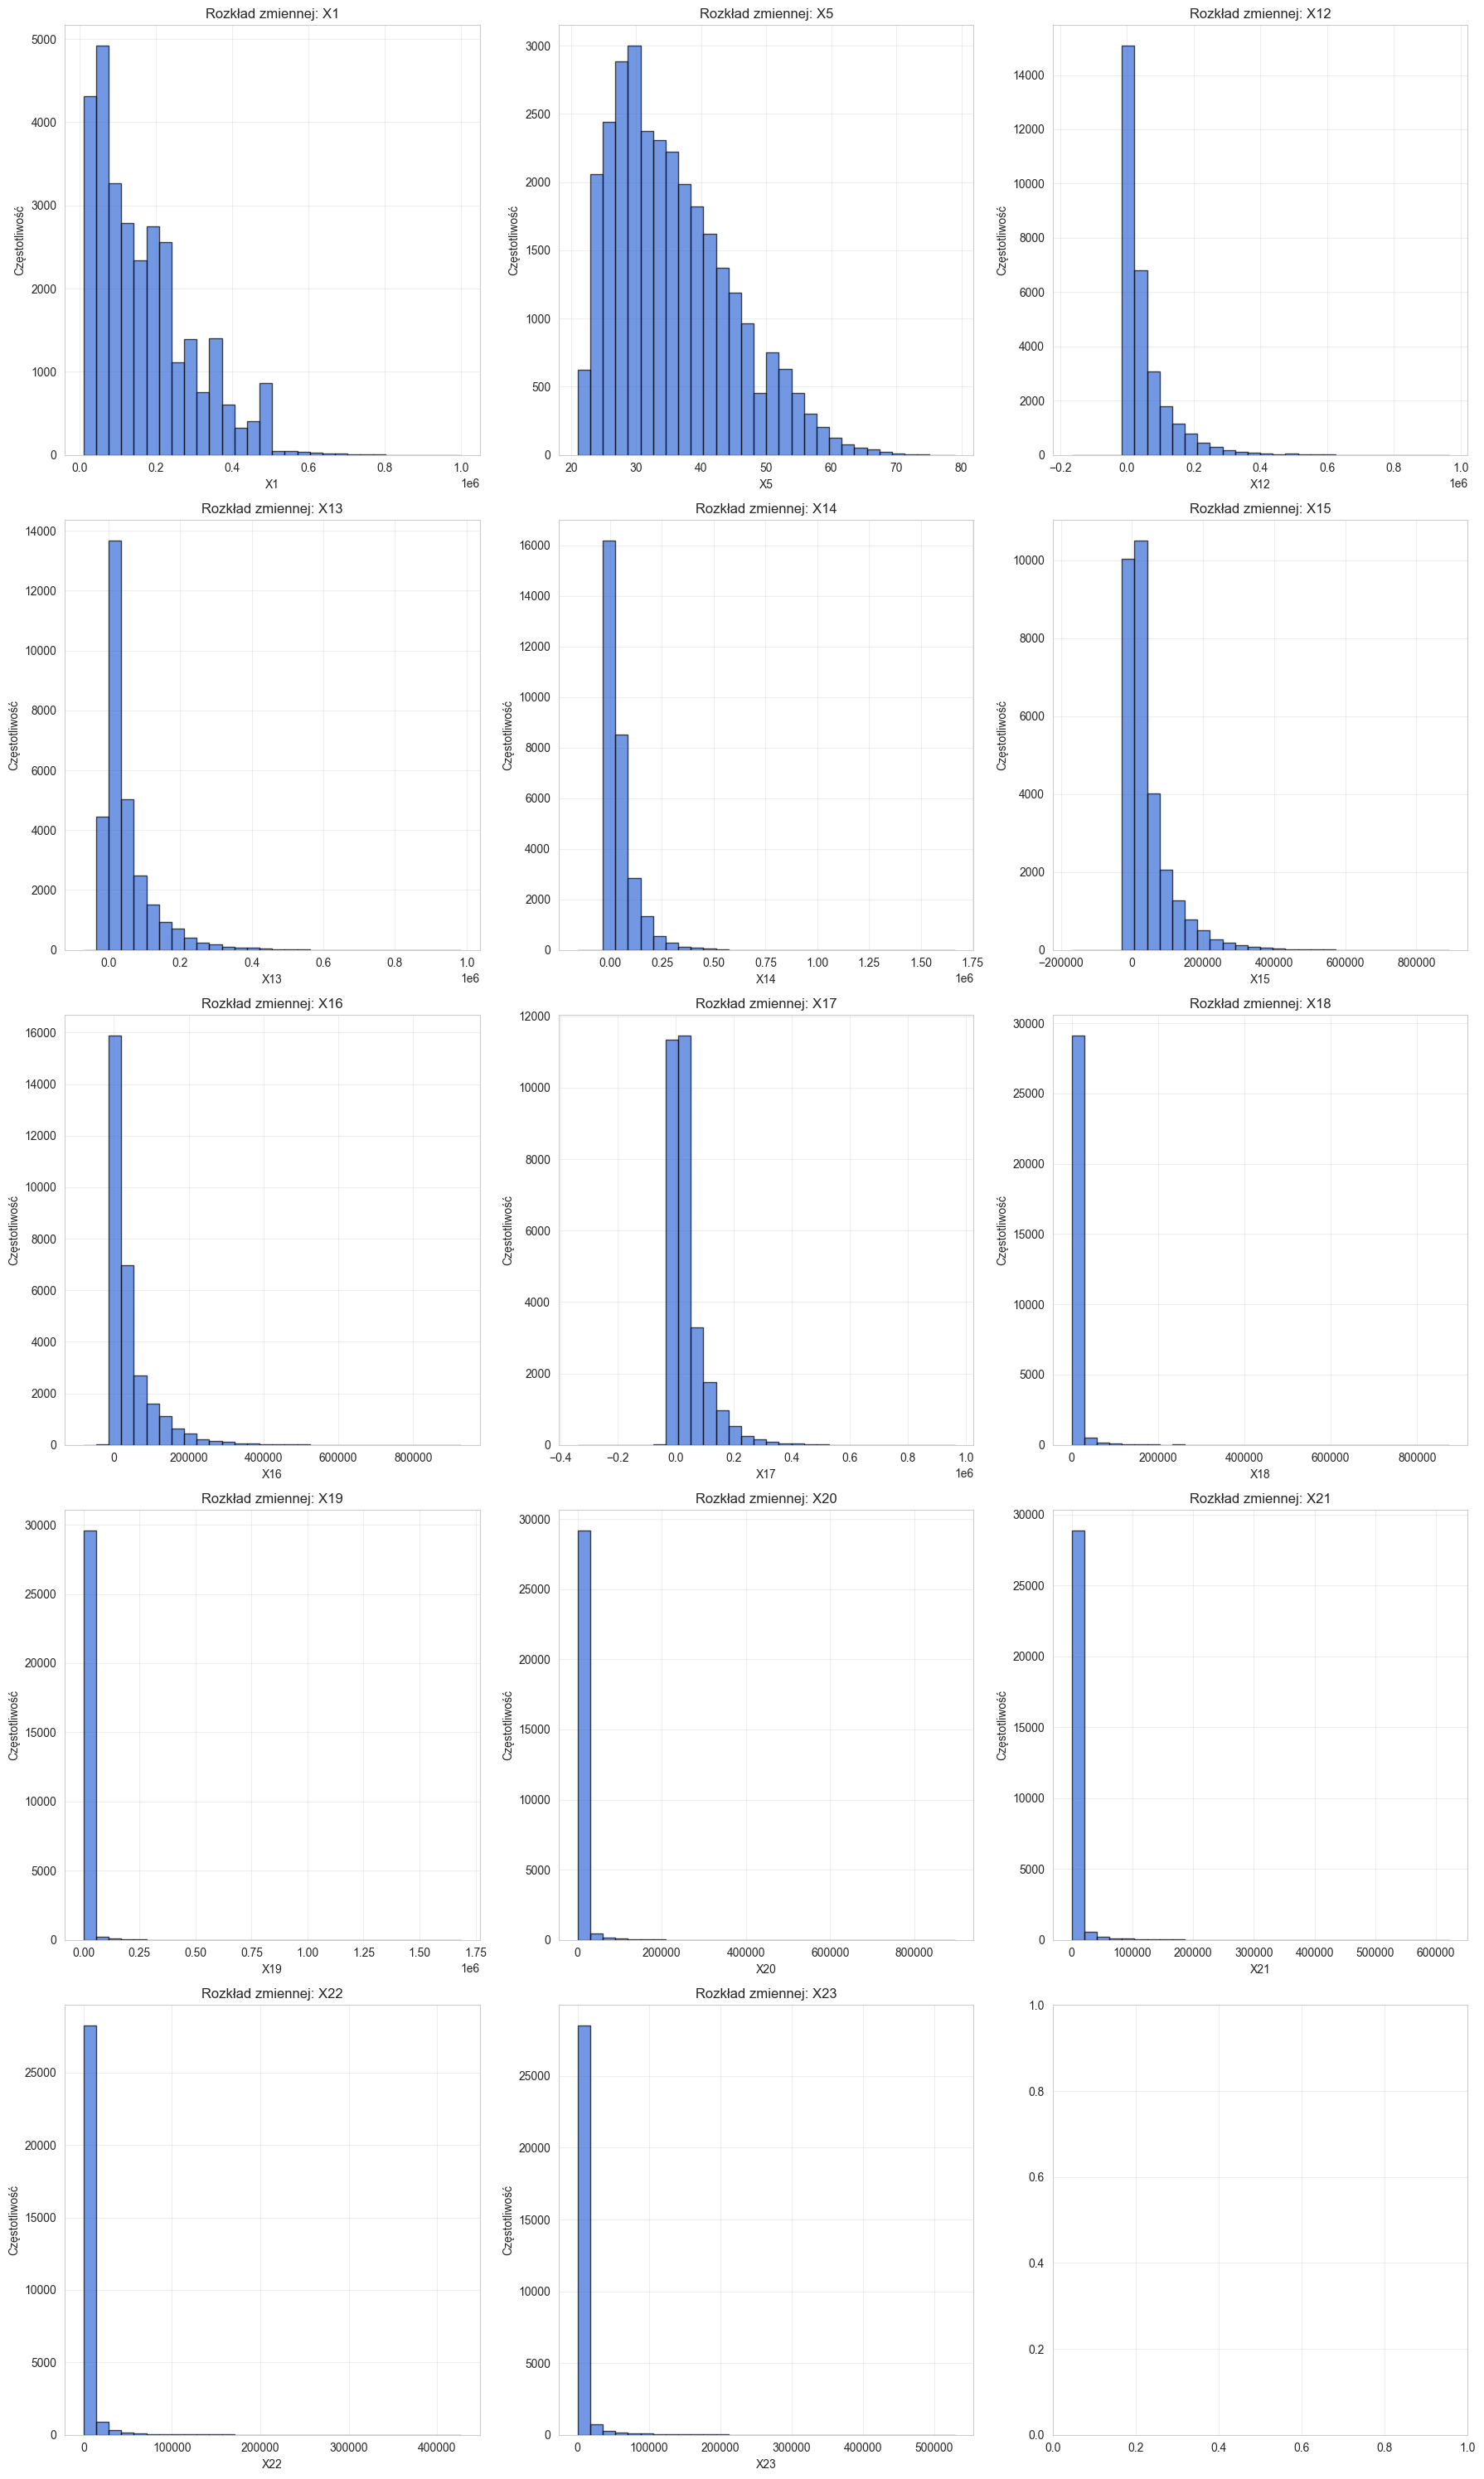

In [132]:
# Histogramy dla zmiennych numerycznych
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

rows = len(numeric_cols) // 3

fig, axes = plt.subplots(rows + 1, 3, figsize=(18, 30))
axes = axes.flatten()

for i, var in enumerate(numeric_cols):
    if var in data.columns:
        axes[i].hist(data[var], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f"Rozkład zmiennej: {var}")
        axes[i].set_xlabel(var)
        axes[i].set_ylabel("Częstotliwość")

plt.tight_layout()
plt.show()

# previous_payment_cols = ["X18", "X19", "X20", "X21", "X22", "X23"]

### Identyfikacja wartości odstających (outliers)

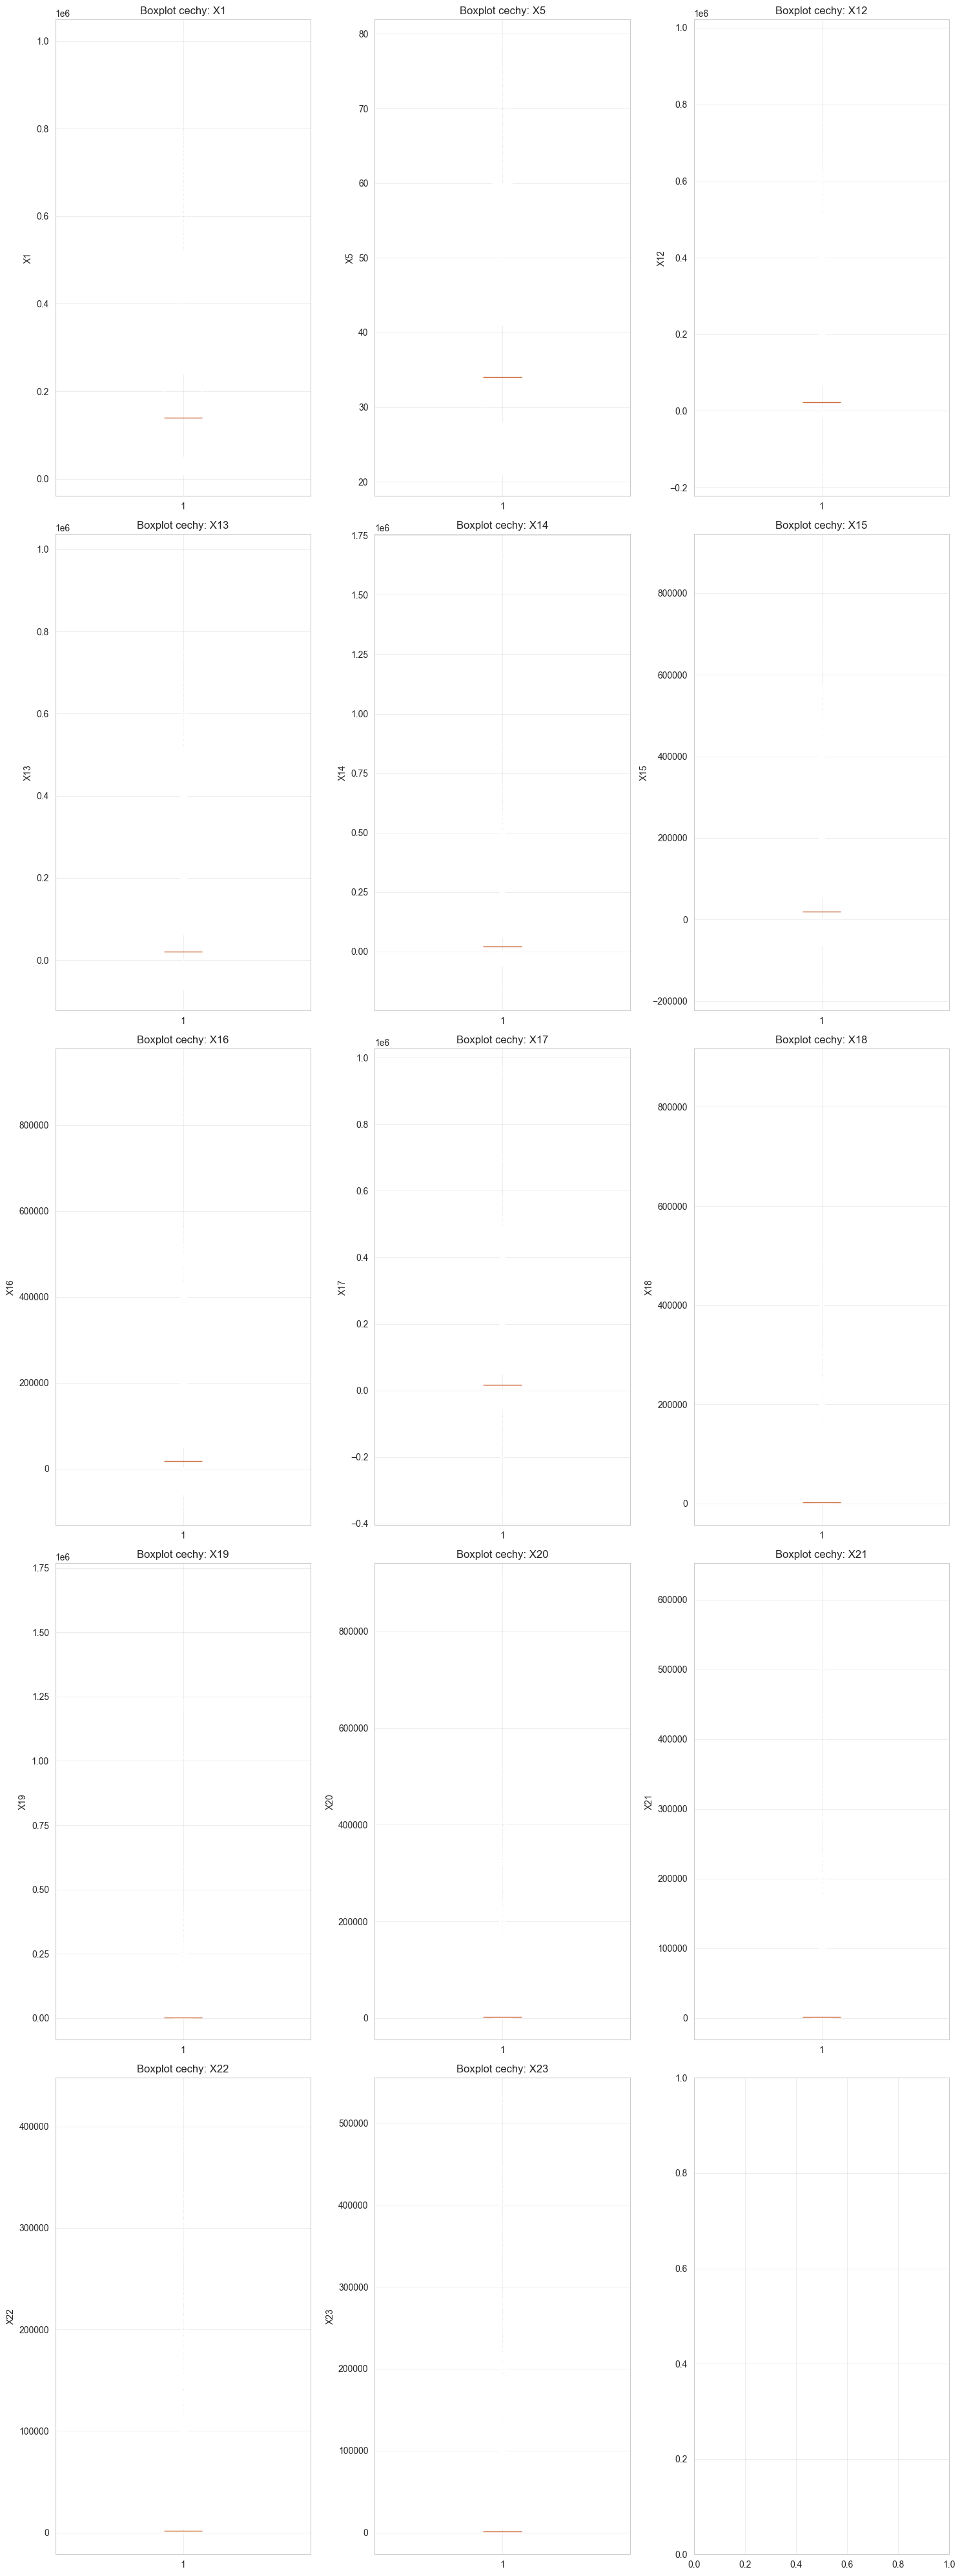

In [136]:


fig, axes = plt.subplots(rows + 1, 3, figsize=(15, 40))
axes = axes.flatten()

# outlier_vars = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2']
for i, var in enumerate(numeric_cols):
    if var in data.columns:
        axes[i].boxplot(data[var])
        axes[i].set_title(f'Boxplot cechy: {var}')
        axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

In [137]:
# Metoda IQR do wykrywania outlierów
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Liczba outlierów (metodą IQR):")
for col in numeric_cols:
    if col in data.columns:
        n_outliers, low, high = count_outliers_iqr(data, col)
        print(f"{col}: {n_outliers} outlierów (zakres: {low:.2f} - {high:.2f})")

Liczba outlierów (metodą IQR):
X1: 167 outlierów (zakres: -235000.00 - 525000.00)
X5: 272 outlierów (zakres: 8.50 - 60.50)
X12: 2400 outlierów (zakres: -91739.62 - 162389.38)
X13: 2395 outlierów (zakres: -88547.50 - 155538.50)
X14: 2469 outlierów (zakres: -83581.50 - 146412.50)
X15: 2622 outlierów (zakres: -75942.12 - 132774.88)
X16: 2725 outlierów (zakres: -70878.25 - 122831.75)
X17: 2693 outlierów (zakres: -70657.38 - 121111.62)
X18: 2745 outlierów (zakres: -5009.00 - 11015.00)
X19: 2714 outlierów (zakres: -5417.50 - 11250.50)
X20: 2598 outlierów (zakres: -5782.50 - 10677.50)
X21: 2994 outlierów (zakres: -5279.88 - 9589.12)
X22: 2945 outlierów (zakres: -5416.00 - 9700.00)
X23: 2958 outlierów (zakres: -5705.62 - 9823.38)


### Wykresy rozrzutu (Scatter plots)

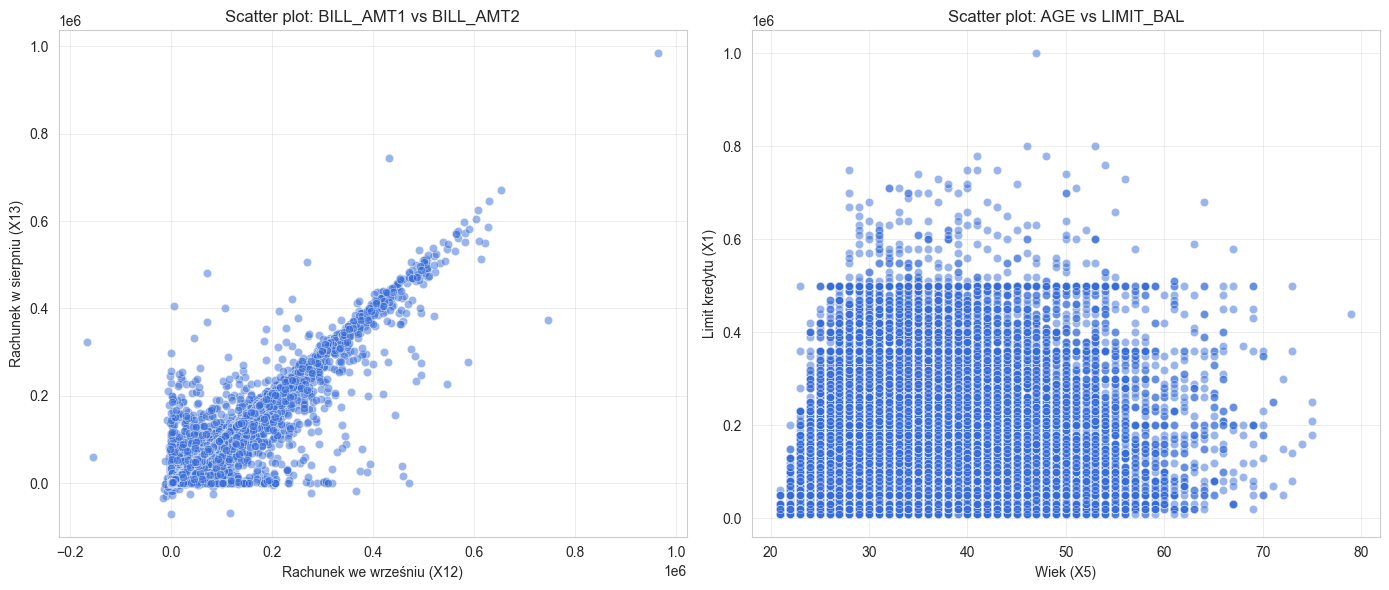

In [177]:
# Wykresy rozrzutu (Scatter plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Przykład 1: Silna korelacja (kwoty rachunków w kolejnych miesiącach)
sns.scatterplot(x='X12', y='X13', data=data, alpha=0.5, ax=axes[0])
axes[0].set_title('Scatter plot: BILL_AMT1 vs BILL_AMT2')
axes[0].set_xlabel('Rachunek we wrześniu (X12)')
axes[0].set_ylabel('Rachunek w sierpniu (X13)')

# Przykład 2: Brak korelacji (Wiek vs Kwota udzielonego kredytu)
sns.scatterplot(x='X5', y='X1', data=data, alpha=0.5, ax=axes[1])
axes[1].set_title('Scatter plot: AGE vs LIMIT_BAL')
axes[1].set_xlabel('Wiek (X5)')
axes[1].set_ylabel('Limit kredytu (X1)')

plt.tight_layout()
plt.show()

## Krok 4: Analiza zależności między zmiennymi (korelacje)

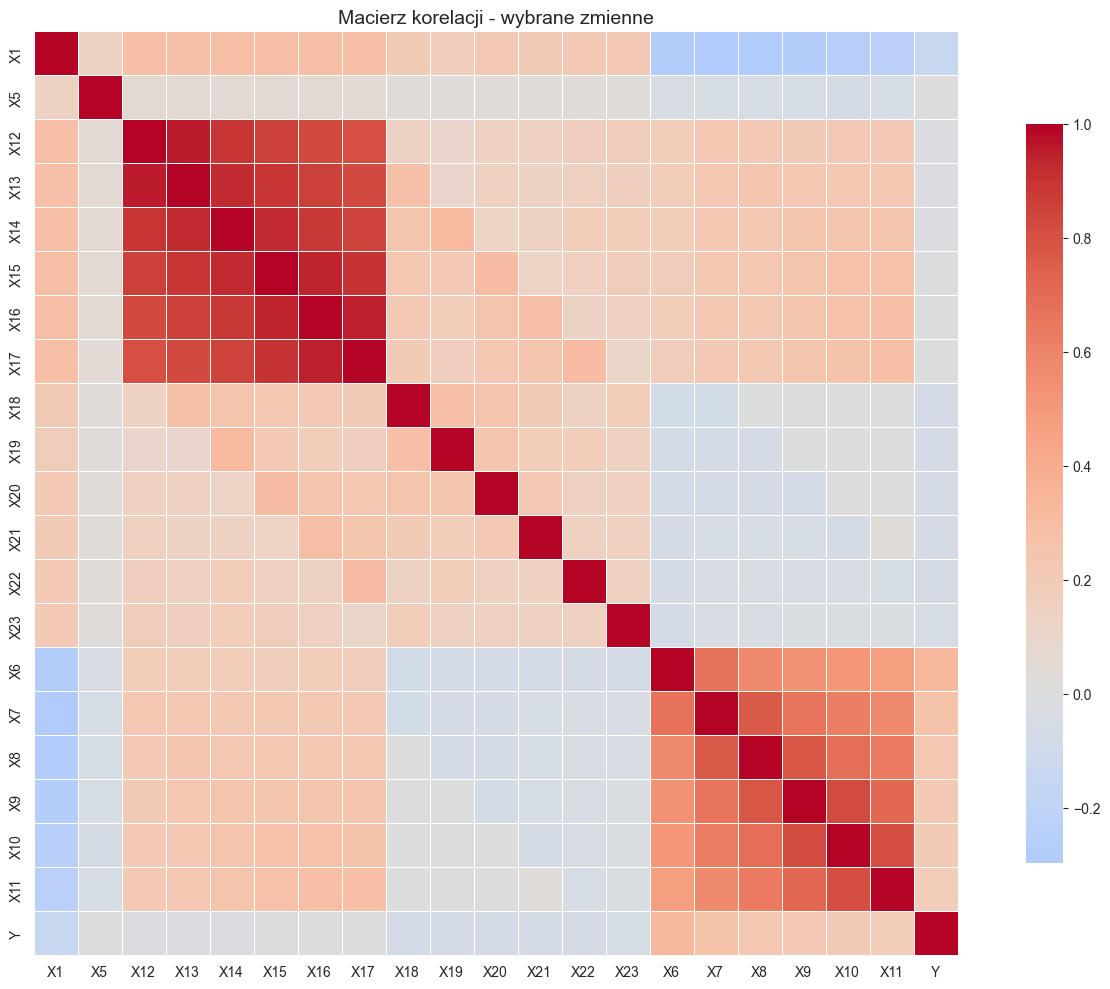

In [157]:
# Macierz korelacji dla wybranych zmiennych
selected_for_corr = numeric_cols + payment_history_features + ["Y"]

corr_matrix = data[selected_for_corr].corr()

# %%
# Heatmapa korelacji
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Macierz korelacji - wybrane zmienne', fontsize=14)
plt.tight_layout()
plt.show()

In [158]:

# Najsilniejsze korelacje ze zmienną docelową
target_corr = corr_matrix['Y'].sort_values(ascending=False)
print("\nKorelacje ze zmienną docelową 'default payment next month':")
print(target_corr)


Korelacje ze zmienną docelową 'default payment next month':
Y      1.000000
X6     0.324794
X7     0.263551
X8     0.235253
X9     0.216614
X10    0.204149
X11    0.186866
X5     0.013890
X17   -0.005372
X16   -0.006760
X15   -0.010156
X14   -0.014076
X13   -0.014193
X12   -0.019644
X23   -0.053183
X22   -0.055124
X20   -0.056250
X21   -0.056827
X19   -0.058579
X18   -0.072929
X1    -0.153520
Name: Y, dtype: float64


## Krok 5: Wstępne obserwacje (Wnioski)

In [159]:
print("=" * 60)
print("WSTĘPNE OBSERWACJE - PODSUMOWANIE")
print("=" * 60)

print("\n1. Podstawowe charakterystyki danych:")
print(f"   - Liczba obserwacji: {len(data)}")
print(f"   - Liczba zmiennych: {len(data.columns)}")
print(f"   - Default rate: {data['Y'].mean()*100:.2f}%")

print("\n2. Braki i anomalie:")
print(f"   - Zbiór danych {missing_result} brakujących wartości")
print("    - Zmienne X6-X11 (PAY_*) przyjmują wartości od -2 do 8")

_display_values_1 = pd.DataFrame(education_not_allowed_values["X3"].value_counts()).T.columns.tolist()
print(f"    - W EDUCATION występują wartości {_display_values_1} (niestandardowe)")

_display_values_2 = pd.DataFrame(marital_status_not_allowed_values["X4"].value_counts()).T.columns.tolist()
print(f"    - W MARRIAGE występują wartości {_display_values_2} (niestandardowe)")

print("\n3. Zależności między zmiennymi:")
print("   - PAY_0, PAY_2,...,PAY_6 są silnie skorelowane między sobą")
print("   - BILL_AMT1...BILL_AMT6 również silnie skorelowane")
print("   - Najsilniejsza korelacja z default: PAY_0 (ok. 0.32)")

print("\n4. Dalsze przetwarzanie:")
print(f"   - Oczyścić kategorie EDUCATION ({_display_values_1} -> 4)")
print(f"   - Oczyścić kategorie MARRIAGE ({_display_values_2} -> 3)")
print("   - Rozważyć standaryzację dla modeli wrażliwych na skalę")


WSTĘPNE OBSERWACJE - PODSUMOWANIE

1. Podstawowe charakterystyki danych:
   - Liczba obserwacji: 30000
   - Liczba zmiennych: 25
   - Default rate: 22.12%

2. Braki i anomalie:
   - Zbiór danych nie zawiera brakujących wartości
    - Zmienne X6-X11 (PAY_*) przyjmują wartości od -2 do 8
    - W EDUCATION występują wartości [5, 6, 0] (niestandardowe)
    - W MARRIAGE występują wartości [0] (niestandardowe)

3. Zależności między zmiennymi:
   - PAY_0, PAY_2,...,PAY_6 są silnie skorelowane między sobą
   - BILL_AMT1...BILL_AMT6 również silnie skorelowane
   - Najsilniejsza korelacja z default: PAY_0 (ok. 0.32)

4. Dalsze przetwarzanie:
   - Oczyścić kategorie EDUCATION ([5, 6, 0] -> 4)
   - Oczyścić kategorie MARRIAGE ([0] -> 3)
   - Rozważyć standaryzację dla modeli wrażliwych na skalę
